In [310]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.transform import rotation

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

plt.style.use('seaborn-v0_8-whitegrid')

In [311]:
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 50)



In [312]:
df = pd.read_csv('../data/raw/results.csv', low_memory=False)

print(f"Shape: {df.shape}")
print(f"Column count: {len(df.columns)}")
print(f"First 5 column names: {list(df.columns[:5])}")

Shape: (49191, 172)
Column count: 172
First 5 column names: ['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment']


In [313]:
target_col = 'ConvertedCompYearly'
print(f"Target column present: {target_col in df.columns}")

Target column present: True


In [314]:
salary_available = df[target_col].notna().sum()
salary_missing = df[target_col].isna().sum()

print(f'Rows with salary: {salary_available}')
print(f"Rows without salary: {salary_missing}")
print(f"Coverage : {salary_available/len(df) * 100:.1f}%")

Rows with salary: 23947
Rows without salary: 25244
Coverage : 48.7%


In [315]:
df[target_col].dropna().describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

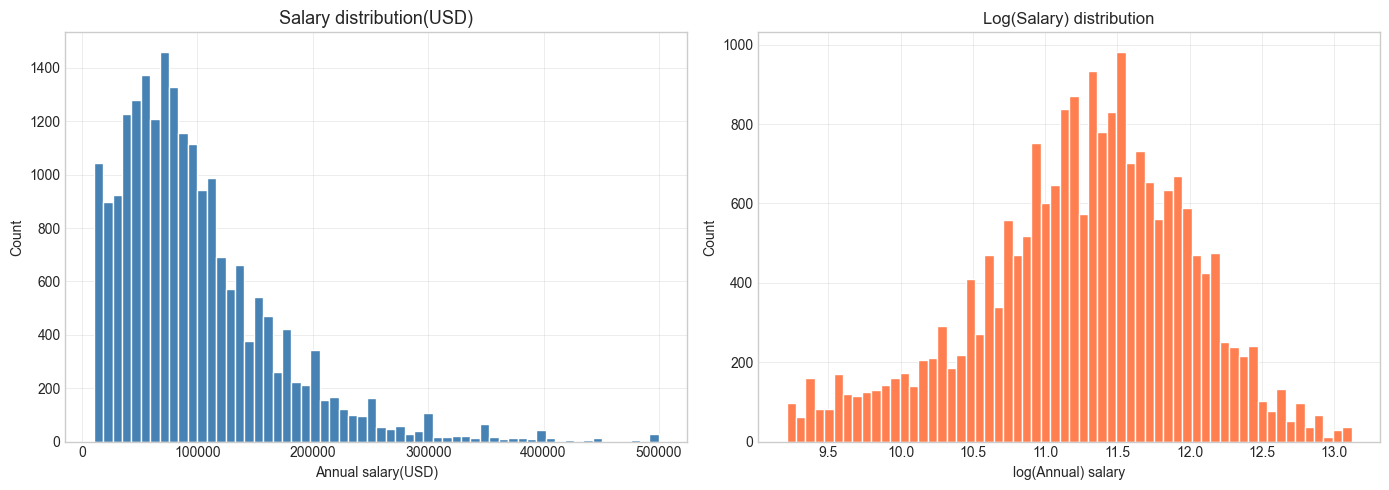

Median salary: $81,870
Mean salary: $98,572


In [316]:
salary_df = df[df[target_col].between(10000, 500000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw distribution
axes[0].hist(salary_df[target_col], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Salary distribution(USD)', fontsize=13)
axes[0].set_xlabel('Annual salary(USD)')
axes[0].set_ylabel('Count')

#log-scale distribution
axes[1].hist(np.log1p(salary_df[target_col]), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Log(Salary) distribution')
axes[1].set_xlabel('log(Annual) salary')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/salary_distribution.png', dpi=300)
plt.show()

print(f"Median salary: ${salary_df[target_col].median():,.0f}")
print(f'Mean salary: ${salary_df[target_col].mean():,.0f}')



In [317]:
df['YearsCode'].nunique()

78

In [318]:
# Explore the selected features.
features = ['Country', 'YearsCodePro', 'Edlevel', 'Employment', 'LanguageHaveWorkedWith']


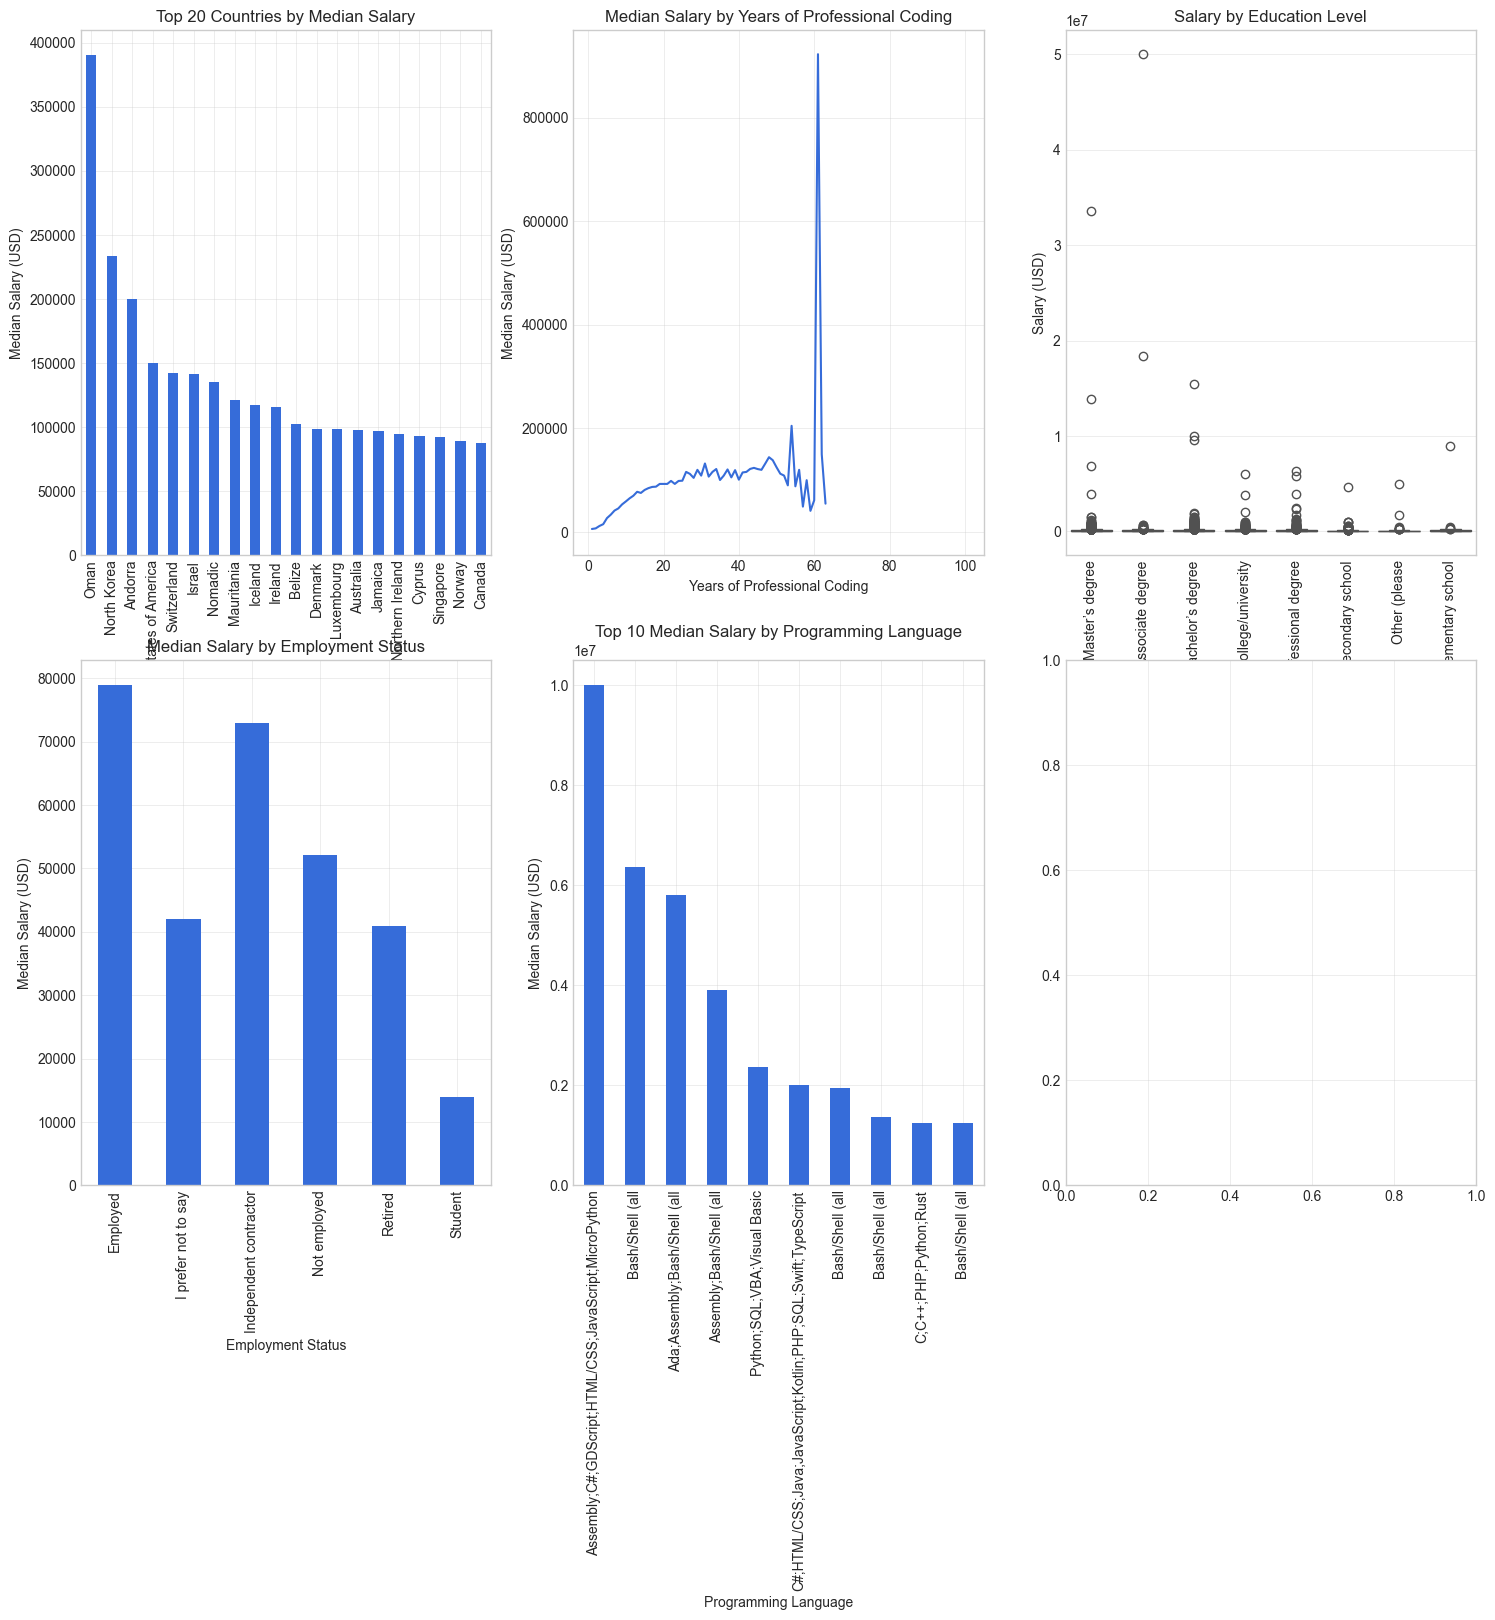


 Visulaization complete. from Cyrus


In [319]:
# FEATURE EXPLORATION
fig, axes = plt.subplots(2, 3, figsize=(18, 15))
# median salary by country
df.groupby('Country')[target_col].median().sort_values(ascending = False).head(20).plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Top 20 Countries by Median Salary')
axes[0,0].set_ylabel('Median Salary (USD)')
axes[0,0].set_xlabel('Country')




df.groupby('YearsCode')[target_col].median().plot(kind='line', ax=axes[0,1])
axes[0,1].set_title('Median Salary by Years of Professional Coding')
axes[0,1].set_ylabel('Median Salary (USD)')
axes[0,1].set_xlabel('Years of Professional Coding')


# boxplot of salary by education level
sns.boxplot(x='EdLevel', y=target_col, data=df, ax=axes[0,2])
axes[0,2].set_title('Salary by Education Level')
axes[0,2].set_xlabel('Education Level')
axes[0,2].set_ylabel('Salary (USD)')
labels = [
    " ".join(label.get_text().split()[:2])
    for label in axes[0, 2].get_xticklabels()
]

axes[0, 2].set_xticks(axes[0, 2].get_xticks())
axes[0, 2].set_xticklabels(labels, rotation=90)



# bar chart of median salary by Enployment cartegory
df.groupby('Employment')[target_col].median().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Median Salary by Employment Status')
axes[1,0].set_xlabel('Employment Status')
axes[1,0].set_ylabel('Median Salary (USD)')
labels = [
    label.get_text().split(",")[0]
    for label in axes[1, 0].get_xticklabels()
]

axes[1, 0].set_xticks(axes[1, 0].get_xticks())
axes[1, 0].set_xticklabels(labels, rotation=90)

# top 10 median salary by programming language

df['LanguageHaveWorkedWith'] = df['LanguageHaveWorkedWith'].fillna('')
language_salary = df.groupby('LanguageHaveWorkedWith')[target_col].median().sort_values(ascending=False).head(10)
language_salary.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Top 10 Median Salary by Programming Language')
axes[1,1].set_xlabel('Programming Language')
axes[1,1].set_ylabel('Median Salary (USD)')
labels = [
    " ".join(label.get_text().split()[:2])
    for label in axes[1, 1].get_xticklabels()
]

axes[1, 1].set_xticks(axes[1, 1].get_xticks())
axes[1, 1].set_xticklabels(labels, rotation=90)



plt.savefig('../data/features_distribution.png', dpi=300)
plt.show()

print('\n Visulaization complete. from Cyrus')





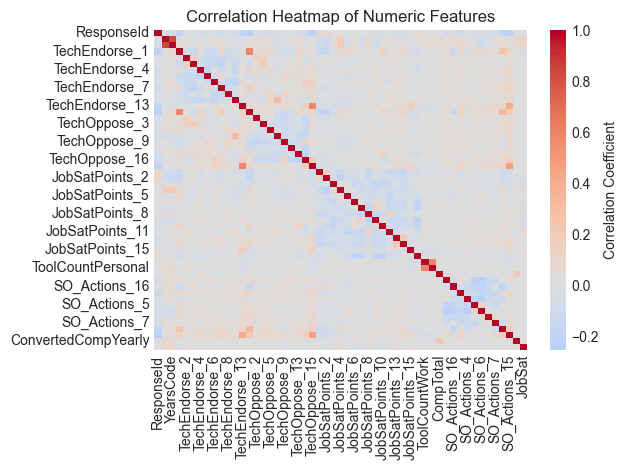

In [320]:
# correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm', center=0, cbar_kws = {'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=300)
plt.show()


In [321]:
# 3. Missing values.
print("Missing values: ")
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'count': missing,
    'percentage': missing_pct
})

print(missing_df[missing_df['count'] > 0].sort_values('percentage', ascending=False))

Missing values: 
                   count  percentage
AIAgentObsWrite    48927   99.463316
SOTagsWant Entry   48761   99.125856
SOTagsHaveEntry    48733   99.068935
AIModelsWantEntry  48716   99.034376
AIAgentOrchWrite   48713   99.028278
...                  ...         ...
EmploymentAddl      4316    8.773963
LearnCodeAI         3990    8.111240
LearnCodeChoose     2333    4.742737
EdLevel             1042    2.118274
Employment           852    1.732024

[168 rows x 2 columns]


In [322]:
df[target_col].isnull().sum()

np.int64(25244)

In [323]:
# EDA findings summary
print("=" * 60)
print("EDA Findings Summary:")
print("-" * 60)
print(f"1. Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\n2. Missing data:\n{missing_df[missing_df['count'] > 0].sort_values('percentage', ascending=False)}")
print(f"\n3. target missing: {df[target_col].isnull().sum()} rows ({df[target_col].isnull().mean() * 100:.1f}%)")
print(f"\n4. Correlation with target:\n{df[numeric_cols].corrwith(df[target_col]).sort_values(ascending=False)}")
print("\n5. Key insights:")
print("- Salary distribution is right-skewed, with a median around $70k and mean around $90k.")
print("- Higher median salaries observed in countries like the US, Switzerland, and Australia.")
print("- Median salary increases with years of professional coding experience, especially after 5 years.")
print("- Education level shows a positive correlation with salary, with those holding a Master's or Doctorate earning more on average.")
print("- Employment status impacts salary, with full-time employees earning significantly more than freelancers or part-time workers.")
print("- Certain programming languages (e.g., Scala, Go, Rust) are associated with higher median salaries, though this may be influenced by other factors like experience and location.")
print("- Correlation heatmap indicates that years of coding experience and education level have moderate positive correlations with salary, while other numeric features show weaker correlations.")
print("=" * 60)

EDA Findings Summary:
------------------------------------------------------------
1. Dataset shape: 49191 rows x 172 columns

2. Missing data:
                   count  percentage
AIAgentObsWrite    48927   99.463316
SOTagsWant Entry   48761   99.125856
SOTagsHaveEntry    48733   99.068935
AIModelsWantEntry  48716   99.034376
AIAgentOrchWrite   48713   99.028278
...                  ...         ...
EmploymentAddl      4316    8.773963
LearnCodeAI         3990    8.111240
LearnCodeChoose     2333    4.742737
EdLevel             1042    2.118274
Employment           852    1.732024

[168 rows x 2 columns]

3. target missing: 25244 rows (51.3%)

4. Correlation with target:
ConvertedCompYearly    1.000000
CompTotal              0.222443
YearsCode              0.057783
WorkExp                0.054134
JobSatPoints_4         0.032147
JobSatPoints_6         0.025728
JobSat                 0.023568
TechOppose_13          0.016289
SO_Actions_3           0.016181
JobSatPoints_8         0.015870


In [324]:
# drop the columns with more than 50% missing values
threshold = 55
cols_to_drop = missing_df[missing_df['percentage'] > threshold].index
print(f"Columns to drop (>{threshold}% missing): {list(cols_to_drop)}")
df_cleaned = df.drop(columns=cols_to_drop)

Columns to drop (>55% missing): ['TechEndorse_13_TEXT', 'TechOppose_15_TEXT', 'JobSatPoints_15_TEXT', 'LanguagesHaveEntry', 'LanguagesWantEntry', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'DatabaseHaveEntry', 'DatabaseWantEntry', 'PlatformWantToWorkWith', 'PlatformAdmired', 'PlatformHaveEntry', 'PlatformWantEntry', 'WebframeWantToWorkWith', 'WebframeAdmired', 'WebframeHaveEntry', 'WebframeWantEntry', 'DevEnvsWantToWorkWith', 'DevEnvsAdmired', 'DevEnvHaveEntry', 'DevEnvWantEntry', 'SOTagsHaveWorkedWith', 'SOTagsWantToWorkWith', 'SOTagsAdmired', 'SOTagsHaveEntry', 'SOTagsWant Entry', 'OfficeStackHaveEntry', 'OfficeStackWantEntry', 'CommPlatformHaveEntr', 'CommPlatformWantEntr', 'AIModelsHaveWorkedWith', 'AIModelsWantToWorkWith', 'AIModelsAdmired', 'AIModelsHaveEntry', 'AIModelsWantEntry', 'SO_Actions_15_TEXT', 'AIToolCurrently partially AI', 'AIToolPlan to mostly use AI', 'AIToolCurrently mostly AI', 'AIAgent_Uses', 'AgentUsesGeneral', 'AIAgentImpactSomewhat agree', 'AIAgentImpactNeut

In [325]:
drop_cols = [
    "ResponseId",
    "Currency",
    "CompTotal",

    "EmploymentAddl",
    "LearnCodeAI",
    "AILearnHow",
    "TechEndorseIntro",
    "AIThreat",
    "NewRole",

    "LanguageChoice",
    "LanguageWantToWorkWith",
    "LanguageAdmired",
    "DatabaseChoice",
    "PlatformChoice",
    "WebframeChoice",
    "DevEnvsChoice",
    "OfficeStackAsyncWantToWorkWith",
    "OfficeStackAsyncAdmired",
    "CommPlatformWantToWorkWith",
    "CommPlatformAdmired",
    "AIModelsChoice",

    "SOAccount",
    "SOVisitFreq",
    "SODuration",
    "SOPartFreq",
    "SO_Dev_Content",
    "SOComm",
    "SOFriction",
    "AISelect",
    "AISent",
    "AIAcc",
    "AIComplex",
    "AIToolDon't plan to use AI for this task",
    "AIToolPlan to partially use AI",
    "AIFrustration",
    "AIExplain",
    "AIAgents",
    "AIAgentChange",
    "AIAgentChallengesStrongly agree",
    "AIHuman",
    "AIOpen",
]
pattern_drop_prefixes = [
    "TechEndorse_",
    "TechOppose_",
    "JobSatPoints_",
    "SO_Actions_",
]

drop_cols = [col for col in drop_cols if col in df_cleaned.columns]

pattern_drop = [
    col
    for col in df_cleaned.columns
    if any(col.startswith(prefix) for prefix in pattern_drop_prefixes)
]

df_cleaned = df.drop(columns=drop_cols + pattern_drop, errors="ignore")

In [326]:
to_drop = [
    "ToolCountWork",
    "ToolCountPersonal",
    "JobSat",
    "MainBranch",
    "LearnCodeChoose",
    "LearnCode",
    "ICorPM",
    "PurchaseInfluence",
    "TechEndorse_13_TEXT",
    "TechOppose_15_TEXT",
    "JobSatPoints_15_TEXT",
    "LanguagesHaveEntry",
    "LanguagesWantEntry",
    "DatabaseHaveWorkedWith",
    "DatabaseWantToWorkWith",
    "DatabaseAdmired",
    "DatabaseHaveEntry",
    "DatabaseWantEntry",
    "PlatformHaveWorkedWith",
    "PlatformWantToWorkWith",
    "PlatformAdmired",
    "PlatformHaveEntry",
    "PlatformWantEntry",
    "WebframeHaveWorkedWith",
    "WebframeWantToWorkWith",
    "WebframeAdmired",
    "WebframeHaveEntry",
    "WebframeWantEntry",
    "DevEnvsHaveWorkedWith",
    "DevEnvsWantToWorkWith",
    "DevEnvsAdmired",
    "DevEnvHaveEntry",
    "DevEnvWantEntry",
    "SOTagsHaveWorkedWith",
    "SOTagsWantToWorkWith",
    "SOTagsAdmired",
    "SOTagsHaveEntry",
    "SOTagsWant Entry",
    "OpSysPersonal use",
    "OpSysProfessional use",
    "OfficeStackAsyncHaveWorkedWith",
    "OfficeStackHaveEntry",
    "OfficeStackWantEntry",
    "CommPlatformHaveWorkedWith",
    "CommPlatformHaveEntr",
    "CommPlatformWantEntr",
    "AIModelsHaveWorkedWith",
    "AIModelsWantToWorkWith",
    "AIModelsAdmired",
    "AIModelsHaveEntry",
    "AIModelsWantEntry",
    "SO_Actions_15_TEXT",
    "AIToolCurrently partially AI",
    "AIToolPlan to mostly use AI",
    "AIToolCurrently mostly AI",
    "AIAgent_Uses",
    "AgentUsesGeneral",
    "AIAgentImpactSomewhat agree",
    "AIAgentImpactNeutral",
    "AIAgentImpactSomewhat disagree",
    "AIAgentImpactStrongly agree",
    "AIAgentImpactStrongly disagree",
    "AIAgentChallengesNeutral",
    "AIAgentChallengesSomewhat disagree",
    "AIAgentChallengesSomewhat agree",
    "AIAgentChallengesStrongly disagree",
    "AIAgentKnowledge",
    "AIAgentKnowWrite",
    "AIAgentOrchestration",
    "AIAgentOrchWrite",
    "AIAgentObserveSecure",
    "AIAgentObsWrite",
    "AIAgentExternal",
    "AIAgentExtWrite",
]
df_cleaned = df_cleaned.drop(columns=to_drop, errors="ignore")

In [327]:
df_cleaned = df_cleaned[df_cleaned[target_col].notna()]
df_cleaned = df_cleaned[df_cleaned[target_col] > 0]

q1 = df_cleaned[target_col].quantile(0.01)
q99 = df_cleaned[target_col].quantile(0.99)
df_cleaned = df_cleaned[(df_cleaned[target_col] >= q1) & (df_cleaned[target_col] <= q99)]

In [328]:
df_cleaned.shape

(23474, 12)

In [329]:
missing_mean = df_cleaned.isnull().mean() * 100
missing = df_cleaned.isnull().sum()
datatypes = df_cleaned.dtypes
new_missing = pd.DataFrame({
    'missing_count': missing,
    'missing_percentage': missing_mean,
    'datatype': datatypes
}).sort_values('missing_percentage', ascending=False)
print(new_missing[new_missing['missing_count'] > 0])

            missing_count  missing_percentage datatype
RemoteWork           2753           11.727869      str
OrgSize              2649           11.284826      str
Industry              857            3.650848      str
WorkExp               456            1.942575  float64
YearsCode             102            0.434523  float64
EdLevel                16            0.068161      str


In [330]:
# PREPROCESSING PIPELINE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer


In [331]:
df_cleaned = df_cleaned.dropna(subset=[target_col])

In [332]:
# Seperate features and target
X = df_cleaned.drop(columns=[target_col])
y = np.log1p(df_cleaned[target_col])

print(f"Features: {list(X.columns)}")
print(f"Shape of features: {X.shape}")
print(f"Target variable: {target_col}")
print(f"Shape of target: {y.shape}")

Features: ['Age', 'EdLevel', 'Employment', 'WorkExp', 'YearsCode', 'DevType', 'OrgSize', 'RemoteWork', 'Industry', 'Country', 'LanguageHaveWorkedWith']
Shape of features: (23474, 11)
Target variable: ConvertedCompYearly
Shape of target: (23474,)


In [333]:
# split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training target: {y_train.shape}")
print(f"Test target: {y_test.shape}")

Training set: (18779, 11)
Test set: (4695, 11)
Training target: (18779,)
Test target: (4695,)


In [334]:
# identify column types
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['str']).columns.tolist()

print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numerical columns: ['WorkExp', 'YearsCode']
Categorical columns: ['Age', 'EdLevel', 'Employment', 'DevType', 'OrgSize', 'RemoteWork', 'Industry', 'Country', 'LanguageHaveWorkedWith']


In [335]:
df[cat_cols].nunique()

Age                           7
EdLevel                       8
Employment                    6
DevType                      32
OrgSize                       9
RemoteWork                    5
Industry                     15
Country                     177
LanguageHaveWorkedWith    15479
dtype: int64

In [336]:
# building the processing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

In [337]:
high_card_cols = [col for col in cat_cols if df[col].nunique() > 20]
low_card_cols = [col for col in cat_cols if df[col].nunique() <= 20]

print(f"High cardinality columns: {high_card_cols}")
print(f"Low cardinality columns: {low_card_cols}")
print(f"Numerical columns: {num_cols}")

High cardinality columns: ['DevType', 'Country', 'LanguageHaveWorkedWith']
Low cardinality columns: ['Age', 'EdLevel', 'Employment', 'OrgSize', 'RemoteWork', 'Industry']
Numerical columns: ['WorkExp', 'YearsCode']


In [338]:
# Build the preprocessing pipeline
from sklearn.preprocessing import OrdinalEncoder
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# High cardinality pipeline
high_card_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown = 'use_encoded_value',
        unknown_value = -1
    ))
])
# low cardinality pipeline
low_card_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',
                              drop = 'first',
                              sparse_output=False,
                              min_frequency = 1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('high_card', high_card_pipeline, high_card_cols),
    ('low_card', low_card_pipeline, low_card_cols)
])

print("Preprocessing pipeline created successfully.")
print(f"Total features to process: {len(num_cols) + len(high_card_cols) + len(low_card_cols)}")

Preprocessing pipeline created successfully.
Total features to process: 11


In [339]:

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from xgboost import XGBRegressor

In [340]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha = 1.0, random_state=42),
    'Lasso Regression': Lasso(
        alpha = 0.1, random_state=42, max_iter=10000
    ),
    'XGBoost': XGBRegressor(n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        verbosity=0,)}
print(f"Total models to evaluate: {len(models)}")
print(list(models.keys()))

Total models to evaluate: 4
['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'XGBoost']


In [341]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import numpy as np

cv = KFold(n_splits=5, shuffle = True, random_state = 42)

scoring = {
    "r2": "r2",
    "neg_mean_absolute_error": "neg_mean_absolute_error",
    "neg_mean_squared_error": "neg_mean_squared_error",
    "neg_root_mean_squared_error": "neg_root_mean_squared_error",
}

def get_pipeline(model):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

def get_predictions(fitted_pipeline, X):
    return fitted_pipeline.predict(X)

def evaluate_test_set(fitted_pipeline, X_test, y_test):
    y_pred = fitted_pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    # Calculate Mean absolute Percentage error
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    metrics = {
        "Test MAE": mae,
        "Test MSE": mse,
        "Test RMSE": rmse,
        "Test MAPE": mape,
        "Test R²": r2,
    }
    return y_pred, None, metrics

In [342]:
X_train.isnull().sum()

Age                          0
EdLevel                     12
Employment                   0
WorkExp                    354
YearsCode                   85
DevType                      0
OrgSize                   2118
RemoteWork                2203
Industry                   686
Country                      0
LanguageHaveWorkedWith       0
dtype: int64

In [309]:
from sklearn.model_selection import cross_validate
cv_results = {}
trained_pipelines = {}
test_predictions = {}
test_scores = {}
import time

for model_name, model in models.items():
    print(f"Cross-validating {model_name}...", end=" ")

    pipe = get_pipeline(model)
    start_time = time.time()

    cv_scores = cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    cv_time = time.time() - start_time

    cv_results[model_name] = {
        "CV R² Mean": cv_scores['test_r2'].mean(),
        "CV R² Std": cv_scores['test_r2'].std(),
        "CV MAE Mean": -cv_scores['test_neg_mean_absolute_error'].mean(),
        "CV MAE Std": cv_scores['test_neg_mean_absolute_error'].std(),
        "CV RMSE Mean": np.sqrt(-cv_scores['test_neg_mean_squared_error'].mean()),
        "CV RMSE Std": np.sqrt(-cv_scores['test_neg_mean_squared_error']).std(),
        "CV Time (s)": round(cv_time, 4),
    }

    fit_start = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - fit_start

    y_pred, y_score, test_metrics = evaluate_test_set(pipe, X_test, y_test)

    cv_results[model_name].update(test_metrics)
    cv_results[model_name]["Fit Time Full Train (s)"] = round(fit_time, 4)

    trained_pipelines[model_name] = pipe
    test_predictions[model_name] = y_pred
    test_scores[model_name] = y_score

    print(
        f"CV R² mean: {cv_results[model_name]['CV R² Mean']:.4f}, "
        f"Test RMSE: {cv_results[model_name]['Test RMSE']:.2f}, "
        f"Test R²: {cv_results[model_name]['Test R²']:.4f}"
    )

print('\nAll models cross-validated, fitted, and evaluated successfully!')

Cross-validating Linear Regression... CV R² mean: 0.2268, Test RMSE: 1.40, Test R²: 0.2068
Cross-validating Ridge Regression... CV R² mean: 0.2269, Test RMSE: 1.40, Test R²: 0.2069
Cross-validating Lasso Regression... CV R² mean: 0.1226, Test RMSE: 1.48, Test R²: 0.1187
Cross-validating XGBoost... CV R² mean: 0.3744, Test RMSE: 1.26, Test R²: 0.3637

All models cross-validated, fitted, and evaluated successfully!


In [343]:
# Results comparison table
results_df = pd.DataFrame(cv_results).T.sort_values(
    "CV R² Mean", ascending=False
)

print("\n" + "=" * 100)
print("MODEL RANKING BY CROSS-VALIDATED F1")
print("=" * 100)
print(results_df.round(4))
print("=" * 100)

best_model_name = results_df.index[0]
best_pipeline = trained_pipelines[best_model_name]

print(f"\n🏆 Best model from CV: {best_model_name}")
print(
    f"CV R² Mean: {results_df.loc[best_model_name, 'CV R² Mean']:.4f} "
    f"+/- {results_df.loc[best_model_name, 'CV R² Std']:.4f}"
)
print(f"Test R²: {results_df.loc[best_model_name, 'Test R²']:.4f}")


MODEL RANKING BY CROSS-VALIDATED F1
                   CV R² Mean  CV R² Std  CV MAE Mean  CV MAE Std  \
XGBoost                0.3744     0.0094       0.7157      0.0127   
Ridge Regression       0.2269     0.0078       0.8438      0.0084   
Linear Regression      0.2268     0.0078       0.8438      0.0084   
Lasso Regression       0.1226     0.0069       0.9362      0.0093   

                   CV RMSE Mean  CV RMSE Std  CV Time (s)  Test MAE  Test MSE  \
XGBoost                  1.2414       0.0201       4.6649    0.7174    1.5788   
Ridge Regression         1.3802       0.0245       3.1447    0.8526    1.9679   
Linear Regression        1.3802       0.0245       9.6081    0.8527    1.9682   
Lasso Regression         1.4702       0.0223       1.7964    0.9386    2.1867   

                   Test RMSE  Test MAPE  Test R²  Fit Time Full Train (s)  
XGBoost               1.2565    10.5617   0.3637                   0.6649  
Ridge Regression      1.4028    12.4543   0.2069           

In [344]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 2, 5, 10],
}

pipe = get_pipeline(xgb)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_score_)
print(search.best_params_)

0.48763435286813034
{'model__subsample': 1.0, 'model__reg_lambda': 1, 'model__reg_alpha': 1, 'model__n_estimators': 600, 'model__min_child_weight': 3, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}


In [345]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import numpy as np

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "model__n_estimators": [400, 600, 800, 1000, 1200, 1500],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1, 0.12, 0.15],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.5, 0.6, 0.7, 0.8],
    "model__min_child_weight": [1, 2, 3, 4, 5],
    "model__gamma": [0, 0.1, 0.3, 0.5, 1],
    "model__reg_alpha": [0.1, 0.5, 1, 2, 5],
    "model__reg_lambda": [0, 0.5, 1, 2, 3],
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=60,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(search.best_score_)
print(search.best_params_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
0.49446636977460756
{'model__subsample': 0.9, 'model__reg_lambda': 0, 'model__reg_alpha': 5, 'model__n_estimators': 1200, 'model__min_child_weight': 3, 'model__max_depth': 2, 'model__learning_rate': 0.15, 'model__gamma': 0.5, 'model__colsample_bytree': 0.5}


In [353]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [1000, 1200, 1400],
    "model__max_depth": [2, 3],
    "model__learning_rate": [0.10, 0.15, 0.20],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.4, 0.5, 0.6],
    "model__min_child_weight": [2, 3, 4],
    "model__gamma": [0.3, 0.5, 0.7],
    "model__reg_alpha": [3, 5, 7],
    "model__reg_lambda": [0, 0.1, 0.5],
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring="r2",
    cv=6,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(search.best_score_)
print(search.best_params_)


Fitting 6 folds for each of 20 candidates, totalling 120 fits
0.4994806101702646
{'model__subsample': 0.9, 'model__reg_lambda': 0, 'model__reg_alpha': 5, 'model__n_estimators': 1400, 'model__min_child_weight': 3, 'model__max_depth': 2, 'model__learning_rate': 0.2, 'model__gamma': 0.5, 'model__colsample_bytree': 0.5}


In [354]:
# best model with hyperparameter tunings
best_xgb_params = {
    "n_estimators": 1200,
    "max_depth": 2,
    "learning_rate": 0.15,
    "subsample": 0.9,
    "colsample_bytree": 0.5,
    "min_child_weight": 3,
    "gamma": 0.5,
    "reg_alpha": 5,
    "reg_lambda": 0,
    "objective": "reg:squarederror",
    "random_state": 42,
    "verbosity": 0,
}

models = {
    "XGBoost": XGBRegressor(**best_xgb_params),
}

print(f"Total models to evaluate: {len(models)}")
print(list(models.keys()))

Total models to evaluate: 1
['XGBoost']


In [355]:
from sklearn.model_selection import cross_validate
cv_results = {}
trained_pipelines = {}
test_predictions = {}
test_scores = {}
import time

for model_name, model in models.items():
    print(f"Cross-validating {model_name}...", end=" ")

    pipe = get_pipeline(model)
    start_time = time.time()

    cv_scores = cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    cv_time = time.time() - start_time

    cv_results[model_name] = {
        "CV R² Mean": cv_scores['test_r2'].mean(),
        "CV R² Std": cv_scores['test_r2'].std(),
        "CV MAE Mean": -cv_scores['test_neg_mean_absolute_error'].mean(),
        "CV MAE Std": cv_scores['test_neg_mean_absolute_error'].std(),
        "CV RMSE Mean": np.sqrt(-cv_scores['test_neg_mean_squared_error'].mean()),
        "CV RMSE Std": np.sqrt(-cv_scores['test_neg_mean_squared_error']).std(),
        "CV Time (s)": round(cv_time, 4),
    }

    fit_start = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - fit_start

    y_pred, y_score, test_metrics = evaluate_test_set(pipe, X_test, y_test)

    cv_results[model_name].update(test_metrics)
    cv_results[model_name]["Fit Time Full Train (s)"] = round(fit_time, 4)

    trained_pipelines[model_name] = pipe
    test_predictions[model_name] = y_pred
    test_scores[model_name] = y_score

    print(
        f"CV R² mean: {cv_results[model_name]['CV R² Mean']:.4f}, "
        f"Test RMSE: {cv_results[model_name]['Test RMSE']:.2f}, "
        f"Test R²: {cv_results[model_name]['Test R²']:.4f}"
    )

print('\nAll models cross-validated, fitted, and evaluated successfully!')

Cross-validating XGBoost... CV R² mean: 0.4949, Test RMSE: 0.96, Test R²: 0.4815

All models cross-validated, fitted, and evaluated successfully!


In [356]:
best_model_name = results_df.index[0]
best_pipeline = trained_pipelines[best_model_name]

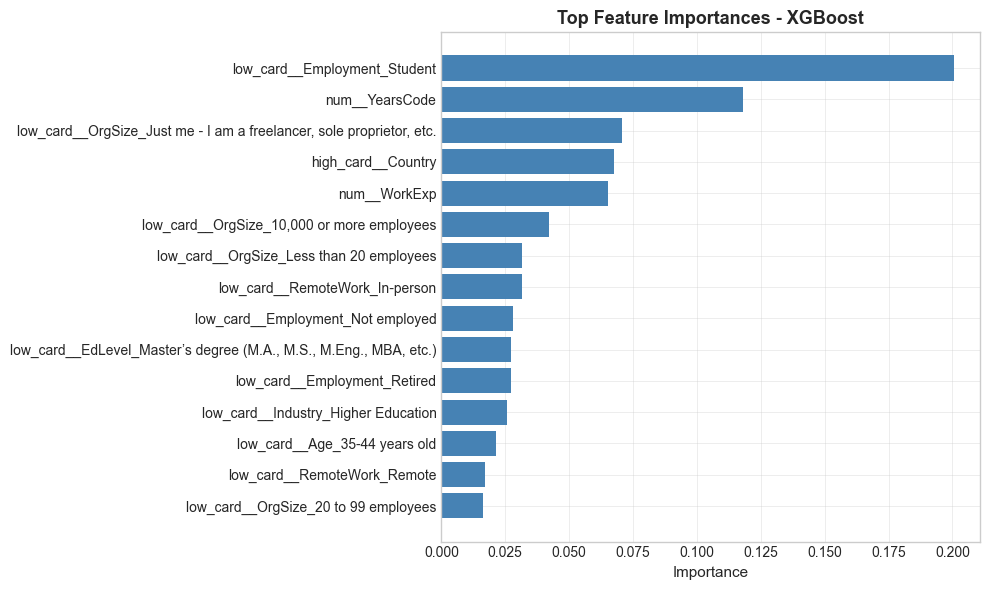


Top Feature Importances:
                                                                 Feature  \
22                                          low_card__Employment_Student   
1                                                         num__YearsCode   
29  low_card__OrgSize_Just me - I am a freelancer, sole proprietor, etc.   
3                                                     high_card__Country   
0                                                           num__WorkExp   
23                            low_card__OrgSize_10,000 or more employees   
30                              low_card__OrgSize_Less than 20 employees   
32                                        low_card__RemoteWork_In-person   
20                                     low_card__Employment_Not employed   
12     low_card__EdLevel_Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   
21                                          low_card__Employment_Retired   
40                                   low_card__Industry_Higher

In [360]:
# best estimator feature importance
best_estimator = best_pipeline.named_steps['model']
if hasattr(best_estimator, "feature_importances_"):
    fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
    feature_names = fitted_preprocessor.get_feature_names_out()

    importance_df = pd.DataFrame(
        {
            "Feature": feature_names,
            'Importance': best_estimator.feature_importances_,
        }
    ).sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df['Feature'][::-1],
        importance_df['Importance'][::-1],
        color = 'steelblue',
    )
    plt.xlabel("Importance", fontsize=11)
    plt.title(
        f"Top Feature Importances - {best_model_name}",
        fontsize = 13,
        fontweight = 'bold',
    )
    plt.tight_layout()
    plt.savefig('../data/feature_importance.png', dpi=300)
    plt.show()

    print("\nTop Feature Importances:")
    print(importance_df)
else:
    print(
        f"Note: {best_model_name} does not provide built-in feature importance scores."
    )

In [358]:
final_model_name = best_model_name
final_pipeline = best_pipeline
final_y_pred = test_predictions[best_model_name]
final_y_score = test_scores[best_model_name]

In [359]:
# saving the model
import joblib
joblib.dump(final_pipeline, "best_pipeline.pkl")
results_df.to_csv("model_results_csv.csv", index=True)

print(f"✅ Final pipeline ({final_model_name}) saved as 'best_pipeline.pkl'")
print("✅ CV + test comparison table saved as 'model_results_cv.csv'")

✅ Final pipeline (XGBoost) saved as 'best_pipeline.pkl'
✅ CV + test comparison table saved as 'model_results_cv.csv'


In [ ]:
# add tech stack
# use CPA
